In [ ]:
import gdown
# Specify the file ID extracted from the Google Drive URL
file_id = '1MbAXGM25COQpi1l6jotaDDLIvMxmiZE8'
# Construct the direct download URL
url = f'https://drive.google.com/uc?id={file_id}'
# Download the file
output = 'netflix_titles.csv'  # The name of the downloaded file
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1MbAXGM25COQpi1l6jotaDDLIvMxmiZE8
To: /content/netflix_titles.csv
100%|██████████| 3.40M/3.40M [00:00<00:00, 25.6MB/s]


'netflix_titles.csv'

# Import the dataset

In [ ]:
import pandas as pd
df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Data cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Check null values

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df[df['date_added'].isnull()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


### Fill NA to Unkown

In [ ]:
df.fillna({'director': 'Unknown',
            'cast': 'Unknown',
            'country': 'Unknown',
            'rating': 'Unknown'},
          inplace=True)

### Check with each row

In [ ]:
# df[df['director	'].isnull()]
# df[df['cast'].isnull()]
# df[df['country'].isnull()]
# df[df['date_added'].isnull()]
# df[df['rating'].isnull()]
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


###Clean duration (Because of wrong input to rating from duration)

In [ ]:
mask = df['duration'].isnull()
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = None

### Leave date_added as Null (Data Integrity)

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,3
duration,0


# Check duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

# Transform the data type

### Convert 'date_added' to datetime format (if it's not already)

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8804 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


### Explor the data

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [ ]:
df['release_year'].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [ ]:
df['country'].value_counts()

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
...,...
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1


In [ ]:
df['director'].value_counts()

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
...,...
"Milla Harrison-Hansley, Alicky Sussman",1
Drew Stone,1
Benjamin Turner,1


In [ ]:
df['listed_in'].sample(20)

,listed_in
3455,Kids' TV
6318,"International TV Shows, TV Dramas, TV Horror"
7406,TV Comedies
1390,Dramas
199,"Comedies, Dramas, International Movies"
193,"International TV Shows, TV Dramas"
8642,Horror Movies
5474,"Action & Adventure, International Movies, Sci-..."
2340,"Dramas, International Movies, Romantic Movies"
1149,"Anime Series, Kids' TV"


In [ ]:
df['duration'].value_counts()


,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
...,...
228 min,1
18 min,1
205 min,1


In [ ]:
df['rating'].value_counts()


,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,3
duration,0


In [ ]:
# Fill missing values in 'director', 'cast', 'country', 'date_added', 'rating', and 'duration' columns with mode values
# 'director' column
df['director'].fillna(df['director'].mode(), inplace=True)

# 'cast' column
# df['cast'].fillna(df["cast"].mode(), inplace=True)  # Dropping 'cast' column later, so filling missing values here won't have an effect

# 'country' column
df['country'].fillna(df['country'].mode(), inplace=True)

# 'date_added' column
df["date_added"].fillna(df['date_added'].mode(), inplace=True)

# 'rating' column
df['rating'].fillna(df['rating'].mode(), inplace=True)

# 'duration' column
df['duration'].fillna(df['duration'].mode(), inplace=True)

# Drop unnecessary columns
# df.drop('cast', axis=1, inplace=True)  # Dropping 'cast' column since it's being filled with mode but dropped later
# df.drop('description', axis=1, inplace=True)  # Dropping 'description' column as it's not used further
# df.drop('title', axis=1, inplace=True)  # Dropping 'title' column as it's not used further

<ipython-input-28-7cce1336dc21>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna(df['director'].mode(), inplace=True)
<ipython-input-28-7cce1336dc21>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

### Change the type of column

In [ ]:
df['show_id']=df['show_id'].str[1:].astype(int)

In [ ]:
#Trend
df['date_added']=pd.to_datetime(df['date_added'],format='mixed')

### Break the listed_in to genres one by one

In [ ]:
df['listed_in'] = df['listed_in'].str.split(', ')

In [ ]:
df['director'] = df['director'].str.split(', ')

In [ ]:
df.rename(columns={'listed_in': 'genres'}, inplace=True)

# Data Visualization

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],Unknown,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm..."
1,2,TV Show,Blood & Water,[Unknown],"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t..."
2,3,TV Show,Ganglands,[Julien Leclercq],"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...
3,4,TV Show,Jailbirds New Orleans,[Unknown],Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo..."
4,5,TV Show,Kota Factory,[Unknown],"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,8803,Movie,Zodiac,[David Fincher],"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"[Cult Movies, Dramas, Thrillers]","A political cartoonist, a crime reporter and a..."
8803,8804,TV Show,Zombie Dumb,[Unknown],Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"[Kids' TV, Korean TV Shows, TV Comedies]","While living alone in a spooky town, a young g..."
8804,8805,Movie,Zombieland,[Ruben Fleischer],"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"[Comedies, Horror Movies]",Looking to survive in a world taken over by zo...
8805,8806,Movie,Zoom,[Peter Hewitt],"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"[Children & Family Movies, Comedies]","Dragged from civilian life, a former superhero..."


In [ ]:
import matplotlib.pyplot as plt

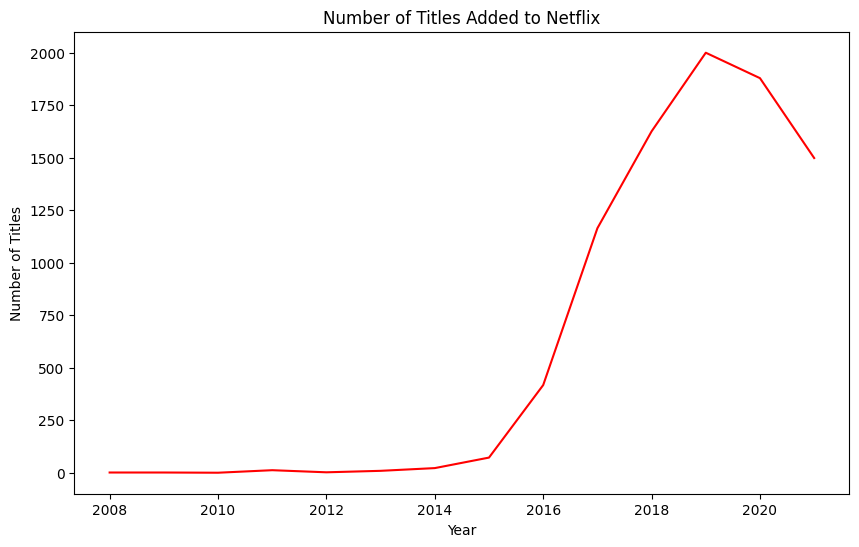

In [ ]:
df['year_added'] = df['date_added'].dt.year

df_movie=df[df['type']=='Movie']
df_tv=df[df['type']=='TV Show']
# Count the number of titles added each year
title_counts = df.groupby('year_added')['show_id'].count()
#movie_counts = df_move.groupby('year_added')['show_id'].count()
#tv_counts = df_tv.groupby('year_added')['show_id'].count()
#Plot the Count the number of Movie and TV in bar chart

# Plot the trend
plt.figure(figsize=(10, 6))
title_counts.plot(kind='line',color='red')
plt.title('Number of Titles Added to Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

# Trend of Movies and TV Shows Added to Netflix

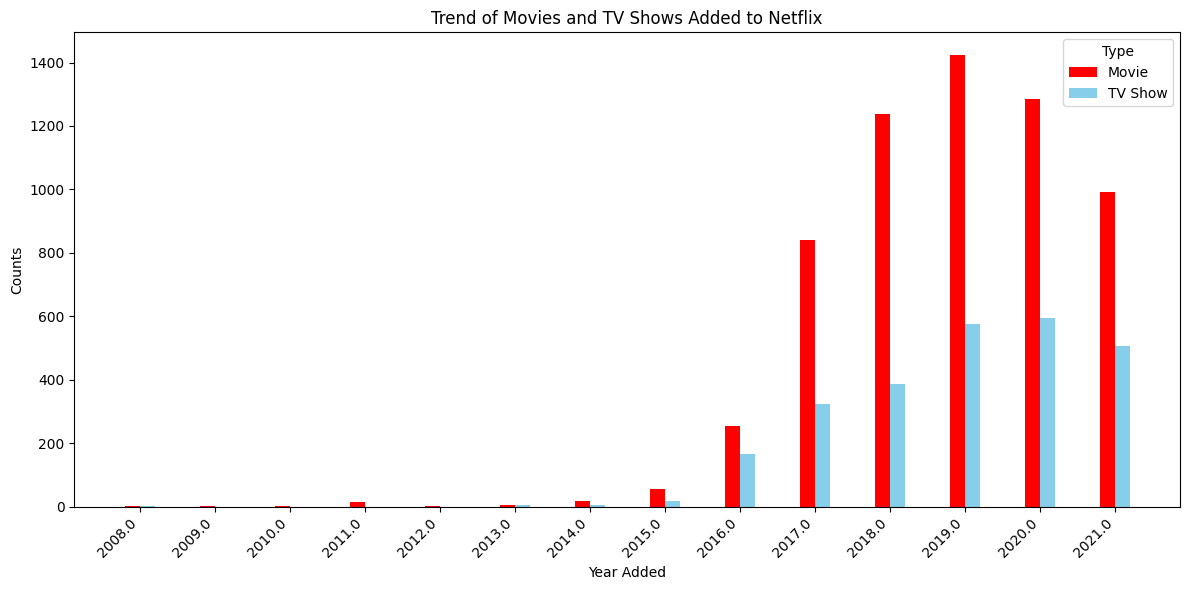

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'df' is your DataFrame with 'date_added' and 'type' columns

# Extract year from 'date_added' and create a new column
df['year_added'] = df['date_added'].dt.year

# Group by 'year_added' and 'type', then count titles
grouped_data = df.groupby(['year_added', 'type'])['show_id'].count().reset_index()

# Pivot the data for plotting
pivoted_data = grouped_data.pivot(index='year_added', columns='type', values='show_id').fillna(0)

# Create the bar chart
plt.figure(figsize=(12, 6))

# Get unique years for x-axis positions
years = pivoted_data.index

# Set bar width
bar_width = 0.2  # Adjust as needed

# Calculate x-axis positions for movies and TV shows
x_pos_movies = np.arange(len(years))
x_pos_tvshows = x_pos_movies + bar_width

# Plot the bars side-by-side
plt.bar(x_pos_movies, pivoted_data['Movie'], width=bar_width, label='Movie', color='red')
plt.bar(x_pos_tvshows, pivoted_data['TV Show'], width=bar_width, label='TV Show', color='skyblue')

# Customize the plot
plt.xlabel('Year Added')
plt.ylabel('Counts')
plt.title('Trend of Movies and TV Shows Added to Netflix')
plt.legend(title='Type')

# Set x-axis ticks to show all years
plt.xticks(x_pos_movies + bar_width / 2, years, rotation=45, ha='right')  # Rotate for readability

plt.tight_layout()
plt.show()

# Genre Distribution for Movies Released in 2018-2019

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,year_added
0,1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],Unknown,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm...",2021.0
1,2,TV Show,Blood & Water,[Unknown],"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2021.0
2,3,TV Show,Ganglands,[Julien Leclercq],"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,2021.0
3,4,TV Show,Jailbirds New Orleans,[Unknown],Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",2021.0
4,5,TV Show,Kota Factory,[Unknown],"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,8803,Movie,Zodiac,[David Fincher],"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"[Cult Movies, Dramas, Thrillers]","A political cartoonist, a crime reporter and a...",2019.0
8803,8804,TV Show,Zombie Dumb,[Unknown],Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"[Kids' TV, Korean TV Shows, TV Comedies]","While living alone in a spooky town, a young g...",2019.0
8804,8805,Movie,Zombieland,[Ruben Fleischer],"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"[Comedies, Horror Movies]",Looking to survive in a world taken over by zo...,2019.0
8805,8806,Movie,Zoom,[Peter Hewitt],"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"[Children & Family Movies, Comedies]","Dragged from civilian life, a former superhero...",2020.0


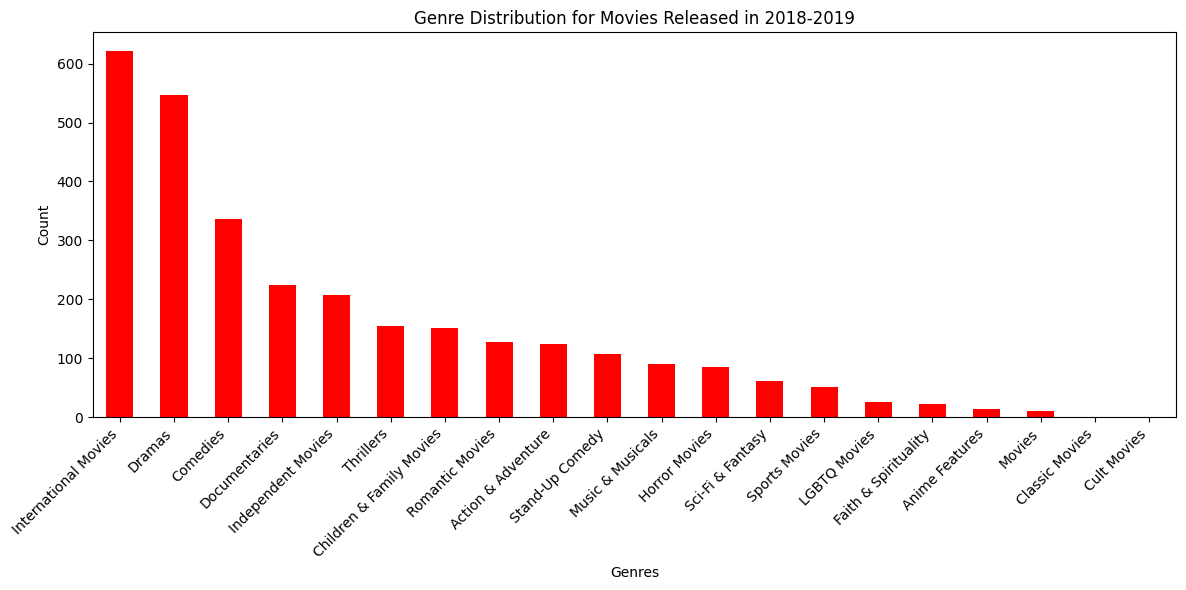

In [ ]:
# Filter for movies released in 2018 and 2019
filtered_df = df[(df['type'] == 'Movie') & (df['release_year'].isin([2018, 2019]))]

# Create a list to store all genres from the filtered DataFrame
all_genres = []
for index in filtered_df.index:
    genres = filtered_df.loc[index, 'genres']
    if isinstance(genres, list):  # Check if it's a list to avoid errors
        all_genres.extend(genres)

# Count the occurrences of each genre
genre_counts = pd.Series(all_genres).value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='red')

# Customize the plot
plt.xlabel('Genres')
plt.ylabel('Count')
plt.title('Genre Distribution for Movies Released in 2018-2019')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()

plt.show()

# Tv Show Distribution for Movies Released in 2018-2019

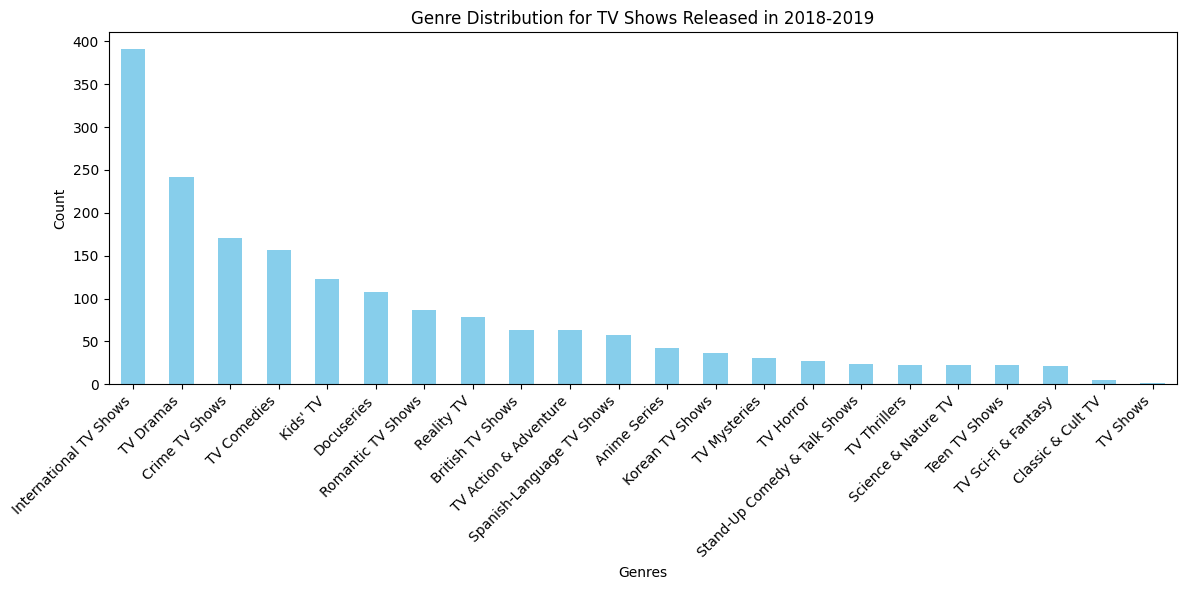

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame with 'genres', 'type', and 'release_year' columns

# Filter for TV shows released in 2018 and 2019
filtered_tvshows = df[(df['type'] == 'TV Show') & (df['release_year'].isin([2018, 2019]))]

# Create a list to store all genres from the filtered DataFrame
all_genres_tvshows = []
for index in filtered_tvshows.index:
    genres = filtered_tvshows.loc[index, 'genres']
    if isinstance(genres, list):
        all_genres_tvshows.extend(genres)

# Count the occurrences of each genre
genre_counts_tvshows = pd.Series(all_genres_tvshows).value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
genre_counts_tvshows.plot(kind='bar', color='skyblue')

# Customize the plot
plt.xlabel('Genres')
plt.ylabel('Count')
plt.title('Genre Distribution for TV Shows Released in 2018-2019')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()

plt.show()

# Top 10 Countries with the most Content on Netflix

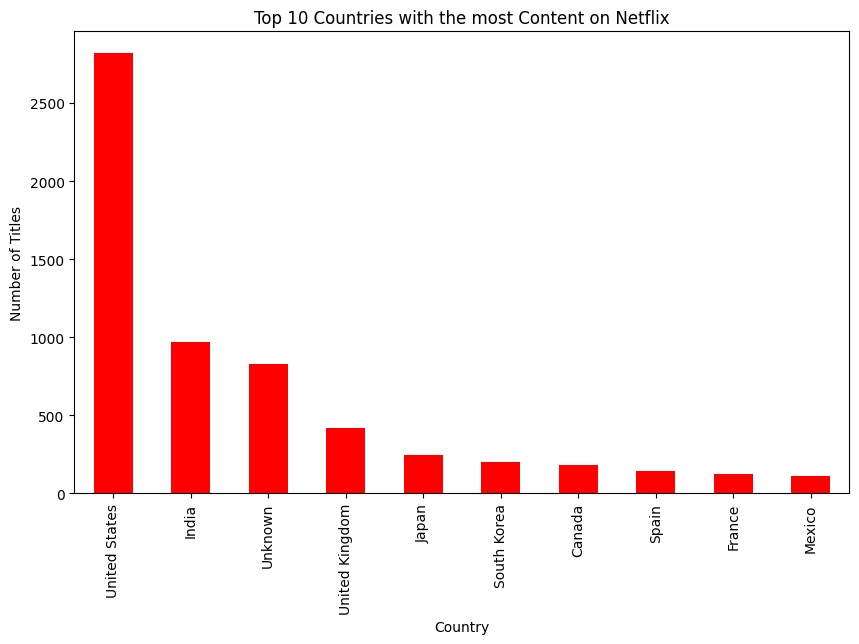

In [ ]:
# count the number of titles available in each country
country_counts = df['country'].value_counts()
#plot the top 10 countries with the most content
plt.figure(figsize=(10,6))
country_counts.head(10).plot(kind='bar', color='red')
plt.title('Top 10 Countries with the most Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90)
plt.show()

# My favourite director Christopher Nolan <img src="https://media.wired.com/photos/648762356279e36472844580/master/w_1920,c_limit/WI070123_FF_ChristopherNolan_01.jpg" height="200">

In [ ]:
# Filter for records with 'nolan' in the director's name (case-insensitive)
nolan_records = df[df['director'].str.contains('nolan', case=False, na=False)]

# Display the filtered records
display(nolan_records)  # Or print(nolan_records) if not using a Jupyter notebook

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,year_added


# let's check the records with Leonardo <img src="https://www.telegraph.co.uk/content/dam/films/2024/11/11/TELEMMGLPICT000401447764_17313251643160_trans_NvBQzQNjv4BqqVzuuqpFlyLIwiB6NTmJwfSVWeZ_vEN7c6bHu2jJnT8.jpeg?imwidth=96024%2F11%2F11%2Fleonardo-dicaprio-at-50-pin-up-dating-love-life%2F&psig=AOvVaw2mGo0bo1_DLWd02ajomTmD&ust=1743258983845000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCPDRjfj_rIwDFQAAAAAdAAAAABAE" alt="drawing" height="200">


In [ ]:
# Assuming 'df' is your DataFrame with a 'cast' column

# Filter for records with 'Leonardo' in the cast's name (case-insensitive)
Leonardo_records = df[(df['cast'].str.contains('Leonardo', case=False, na=False))&(df['type']=='Movie')]
Leonardo_records = Leonardo_records.sort_values(by=['release_year'])
# Display the filtered records
display(Leonardo_records)  # Or print(Leonardo_records) if not using a Jupyter notebook

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,year_added
305,306,Movie,Tango Feroz,[Marcelo Piñeyro],"Fernán Mirás, Cecilia Dopazo, Imanol Arias, Hé...","Argentina, Spain",2021-08-05,1993,TV-MA,124 min,"[Classic Movies, Dramas, International Movies]","One of the first rock stars in Argentina, Tang...",2021.0
1469,1470,Movie,What's Eating Gilbert Grape,[Lasse Hallström],"Johnny Depp, Leonardo DiCaprio, Juliette Lewis...",United States,2021-01-01,1993,PG-13,118 min,"[Classic Movies, Dramas, Independent Movies]","In a backwater Iowa town, young Gilbert is tor...",2021.0
329,330,Movie,Catch Me If You Can,[Steven Spielberg],"Leonardo DiCaprio, Tom Hanks, Christopher Walk...","United States, Canada",2021-08-01,2002,PG-13,142 min,[Dramas],An FBI agent makes it his mission to put cunni...,2021.0
6826,6827,Movie,Gangs of New York,[Martin Scorsese],"Leonardo DiCaprio, Daniel Day-Lewis, Cameron D...","United States, Italy",2019-08-20,2002,R,167 min,[Dramas],In the crime-ridden slums of New York in the 1...,2019.0
8272,8273,Movie,The Departed,[Martin Scorsese],"Leonardo DiCaprio, Matt Damon, Jack Nicholson,...","United States, Hong Kong",2021-01-01,2006,R,151 min,"[Dramas, Thrillers]",Two rookie Boston cops are sent deep undercove...,2021.0
7865,7866,Movie,Revolutionary Road,[Sam Mendes],"Leonardo DiCaprio, Kate Winslet, Kathy Bates, ...","United States, United Kingdom",2019-11-01,2008,R,120 min,"[Dramas, Romantic Movies]",April and Frank's marriage unravels when a pla...,2019.0
1358,1359,Movie,Shutter Island,[Martin Scorsese],"Leonardo DiCaprio, Mark Ruffalo, Ben Kingsley,...",United States,2021-02-01,2010,R,139 min,[Thrillers],A U.S. marshal's troubling visions compromise ...,2021.0
340,341,Movie,Inception,[Christopher Nolan],"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...","United States, United Kingdom",2021-08-01,2010,PG-13,148 min,"[Action & Adventure, Sci-Fi & Fantasy, Thrillers]",A troubled thief who extracts secrets from peo...,2021.0
392,393,Movie,Django Unchained,[Quentin Tarantino],"Jamie Foxx, Christoph Waltz, Leonardo DiCaprio...",United States,2021-07-24,2012,R,165 min,"[Action & Adventure, Dramas]","Accompanied by a German bounty hunter, a freed...",2021.0
5626,5627,Movie,O Silêncio do Céu,[Marco Dutra],"Leonardo Sbaraglia, Carolina Dieckmann, Chino ...",Brazil,2017-01-25,2016,TV-MA,102 min,"[Dramas, International Movies]","After being raped in her home, a married woman...",2017.0


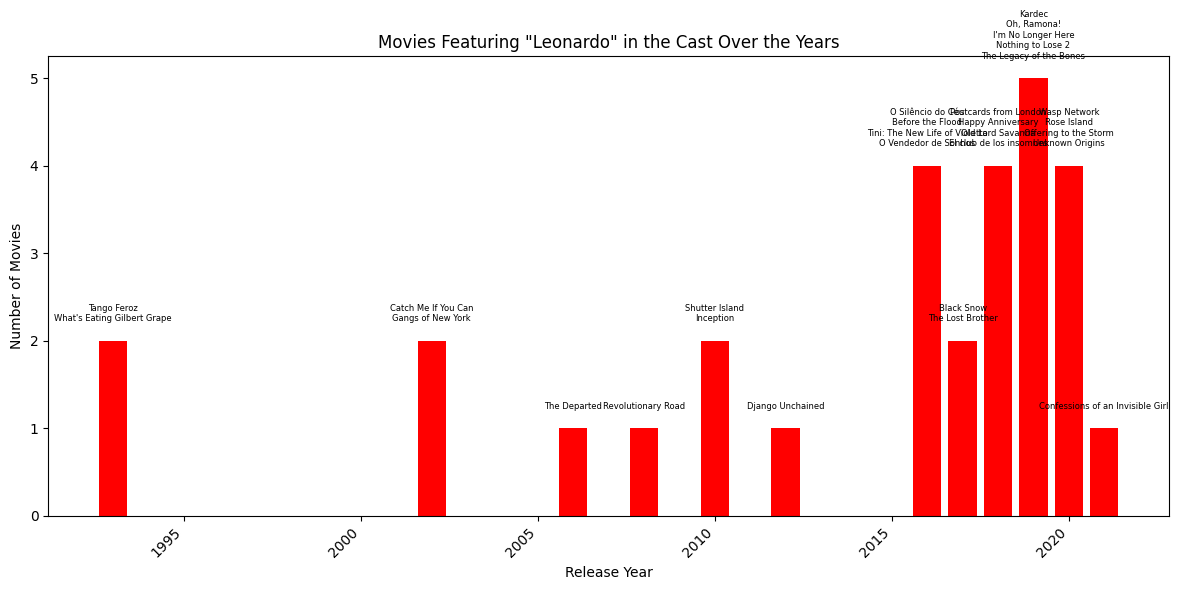

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'Leonardo_records' is already filtered

# Group movies with "Leonardo" by release year and count
Leonardo_movies_by_year = Leonardo_records.groupby('release_year')['title'].agg(['count', 'unique'])

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.bar(Leonardo_movies_by_year.index, Leonardo_movies_by_year['count'], color='red')

# Add movie titles as text annotations
for index, row in Leonardo_movies_by_year.iterrows():
    plt.text(index, row['count'] + 0.2, '\n'.join(row['unique']), ha='center', va='bottom', fontsize=6)

# Customize the plot
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.title('Movies Featuring "Leonardo" in the Cast Over the Years')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()

# Sort 'Leonardo_records' by 'release_year' in ascending order
Leonardo_records_sorted = Leonardo_records.sort_values(by=['release_year'])

# Print year and title for each movie in the sorted DataFrame
#for index, row in Leonardo_records_sorted.iterrows():
#    print(f"Year: {row['release_year']}, Title: {row['title']}")
plt.show()


# Director with the most works

In [ ]:
df[df['director'] != 'Unknown']['director'].value_counts().head(20)

,count
director,
[Unknown],2634
[Rajiv Chilaka],19
"[Raúl Campos, Jan Suter]",18
[Suhas Kadav],16
[Marcus Raboy],16
[Jay Karas],14
[Cathy Garcia-Molina],13
[Martin Scorsese],12
[Youssef Chahine],12


# Productive directors

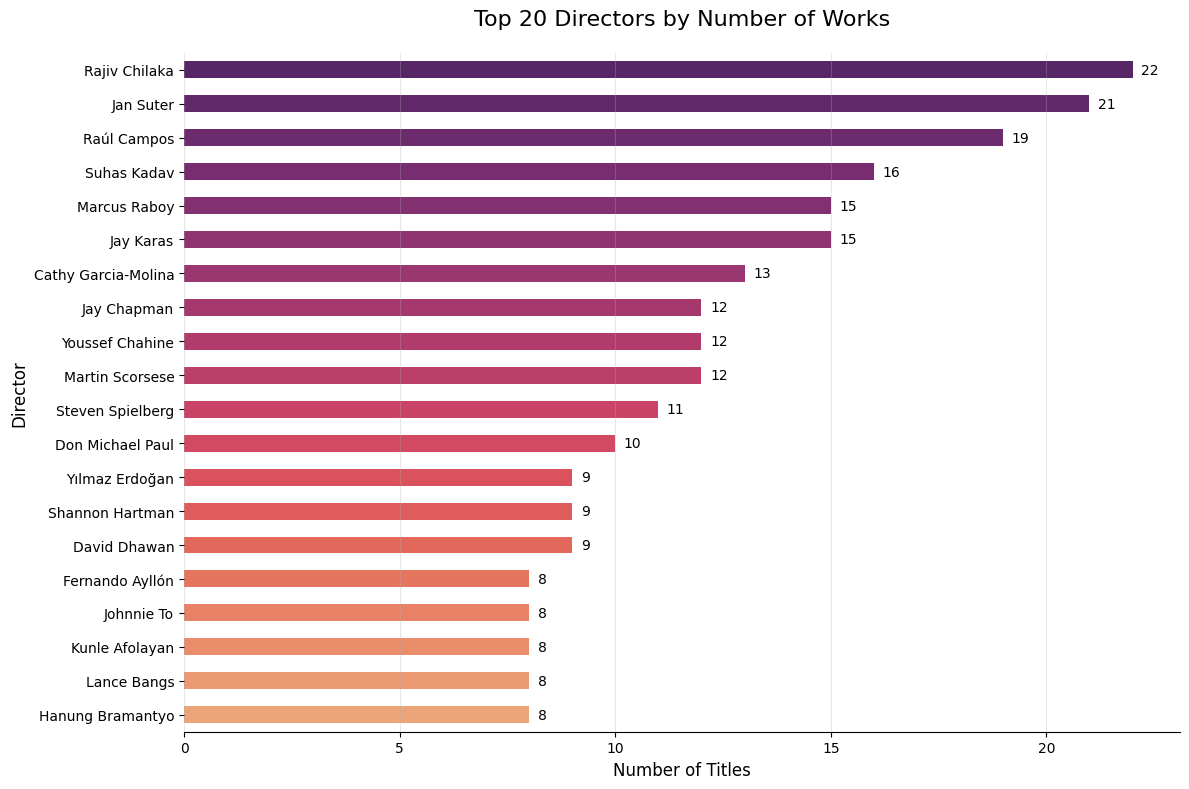

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

most_works_df_film = df_movie
# 1. Explode the lists to get one row per director
exploded_directors = most_works_df_film['director'].explode()

# 2. Filter out None/NaN/Empty strings and 'Unknown' (case insensitive)
director_counts = (exploded_directors[
    exploded_directors.notna() &
    ~exploded_directors.str.lower().eq('unknown')
].value_counts())

# 3. Get top 20 directors
top_directors = director_counts.head(20)

# 4. Create the visualization
plt.figure(figsize=(12, 8))
ax = top_directors.sort_values().plot(
    kind='barh',
    color=sns.color_palette("flare", len(top_directors))
)

# Add value labels
for i, v in enumerate(top_directors.sort_values()):
    ax.text(v + 0.2, i, f"{v}", color='black', va='center')
/
# Styling
plt.title('Top 20 Directors by Number of Works', fontsize=16, pad=20)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.grid(axis='x', alpha=0.3)
sns.despine(left=True)
plt.tight_layout()
plt.show()